<a href="https://colab.research.google.com/github/victormartinezf-droid/deepLearning/blob/main/Lab2_Search_Optimization_Experiments_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 2 — Implementation of AI Search & Optimization Techniques

**Course:** Artificial Intelligence & Deep Learning  
**Exercise:** Maximize a Multimodal Mathematical Function  

## Objective

Maximize:

\[
f(x)=x\sin(10\pi x)+1
\]

subject to:

\[
-1 \leq x \leq 2
\]

The same optimization problem will be studied with:

1. **Hill Climbing**
2. **Simulated Annealing**
3. **Genetic Algorithm**

The goal is **not only to execute code**, but to **modify parameters, repeat experiments, measure results, visualize behavior, and interpret what happens**.

---

## Experimental logic

For every algorithm we will follow:

**Modify one factor → Execute → Measure → Visualize → Interpret**

Main indicators:

- **Best x**: location of the best solution found.
- **Best f(x)**: quality of the best solution.
- **Gap to reference maximum**: distance from the best known reference value.
- **Iterations / generations**: search effort.
- **Success rate**: percentage of repeated runs that reach a solution very close to the reference maximum.
- **Standard deviation**: stability across repeated runs.
- **Accepted worse moves**: specific to Simulated Annealing.
- **Population diversity**: specific to Genetic Algorithm.

> The supplied reference codes use a simpler parabola. This notebook adapts them to the multimodal function required by **Lab 2 Exercise** and adds the experiments requested in the guide.



## 1. Environment and common configuration

Run this cell first. The random seeds are controlled so that the notebook is reproducible. You can later change them to make new experimental runs.


In [ ]:

import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 6)

# Search domain required by the exercise
X_MIN = -1.0
X_MAX = 2.0

# Reproducibility
BASE_SEED = 2026

# A run will be considered successful if its best objective value
# is within this tolerance of the reference maximum.
SUCCESS_TOL = 0.01

print("Environment ready.")


Environment ready.



## 2. Objective function and reference maximum

Before evaluating the algorithms, we need a **common benchmark**.

We approximate the global maximum with a very dense grid over the allowed interval. This reference is not one of the competing algorithms; it only gives us a value against which to compare the quality of the solutions.

We will calculate:

\[
\text{Gap}=f^*_{\mathrm{ref}}-f(x_{\mathrm{algorithm}})
\]

A **smaller gap is better**. A gap close to zero means the algorithm reached a solution very close to the reference maximum.


Reference maximum: x ≈ 1.850550
Reference f(x):     2.850274


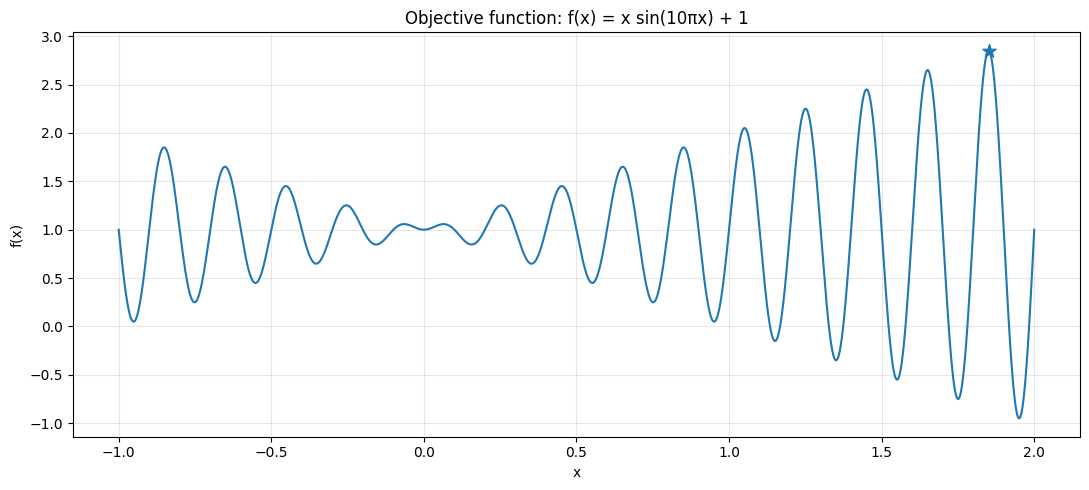

In [ ]:

def objective(x):
    """Required multimodal objective function."""
    return x * np.sin(10 * np.pi * x) + 1

# Dense-grid reference
grid_x = np.linspace(X_MIN, X_MAX, 300_001)
grid_y = objective(grid_x)

ref_idx = int(np.argmax(grid_y))
REF_X = float(grid_x[ref_idx])
REF_F = float(grid_y[ref_idx])

def gap_to_reference(value):
    # REF_F is grid-based, so clip tiny negative differences caused by grid resolution.
    return max(0.0, REF_F - float(value))

print(f"Reference maximum: x ≈ {REF_X:.6f}")
print(f"Reference f(x):     {REF_F:.6f}")

plt.figure(figsize=(11, 5))
plt.plot(grid_x, grid_y)
plt.scatter([REF_X], [REF_F], s=100, marker="*")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Objective function: f(x) = x sin(10πx) + 1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### What to observe

The curve contains several peaks. This is why it is called **multimodal**.

The central experimental question is:

> Can each algorithm find the highest peak, or does it stop at another local peak?



# 3. Experiment A — Hill Climbing

The exercise requires:

- at least **five different starting values**;
- a **fixed step size**;
- recording the final solution for each starting point;
- demonstrating that different starting points can lead to different local optima.

### What we will change

Only the **starting point**.

### What we will keep fixed

- objective function;
- interval;
- step size;
- maximum iterations.

### What we will measure

- Initial x
- Final x
- Final f(x)
- Gap to reference maximum
- Number of iterations
- Whether the reference maximum was reached within the tolerance


In [ ]:

def hill_climbing(initial_x, step_size=0.01, max_iterations=10_000):
    current_x = float(initial_x)
    current_f = float(objective(current_x))
    trajectory = [(0, current_x, current_f)]

    for iteration in range(1, max_iterations + 1):
        left = max(X_MIN, current_x - step_size)
        right = min(X_MAX, current_x + step_size)

        neighbors = [left, right]
        scores = [float(objective(x)) for x in neighbors]

        best_idx = int(np.argmax(scores))
        best_neighbor = neighbors[best_idx]
        best_score = scores[best_idx]

        if best_score > current_f + 1e-12:
            current_x = best_neighbor
            current_f = best_score
            trajectory.append((iteration, current_x, current_f))
        else:
            break

    return {
        "initial_x": float(initial_x),
        "best_x": current_x,
        "best_f": current_f,
        "iterations": len(trajectory) - 1,
        "trajectory": trajectory
    }



## 3.1 Five starting points

You may change these values later. Keep the same step size when comparing the runs.


In [ ]:

HC_STARTS = [-0.90, -0.30, 0.30, 0.90, 1.90]
HC_STEP = 0.01

hc_runs = []

for start in HC_STARTS:
    result = hill_climbing(start, step_size=HC_STEP)

    hc_runs.append({
        "Initial x": result["initial_x"],
        "Final x": result["best_x"],
        "Final f(x)": result["best_f"],
        "Gap": gap_to_reference(result["best_f"]),
        "Iterations": result["iterations"],
        "Success": (gap_to_reference(result["best_f"])) <= SUCCESS_TOL
    })

hc_df = pd.DataFrame(hc_runs)
display(hc_df)


,Initial x,Final x,Final f(x),Gap,Iterations,Success
0,-0.9,-0.85,1.85,1.000274,5,False
1,-0.3,-0.25,1.25,1.600274,5,False
2,0.3,0.25,1.25,1.600274,5,False
3,0.9,0.85,1.85,1.000274,5,False
4,1.9,1.85,2.85,0.000274,5,True



## 3.2 Visual evidence of local optima

The graph displays the five starting points and the final point reached by Hill Climbing.

### What to evaluate

1. Do different starting points finish at different peaks?
2. Which starting point reaches the reference global maximum?
3. Which runs stop with a positive gap?
4. If a run stops at a lower peak even though a higher peak exists, that is direct experimental evidence of a **local optimum**.


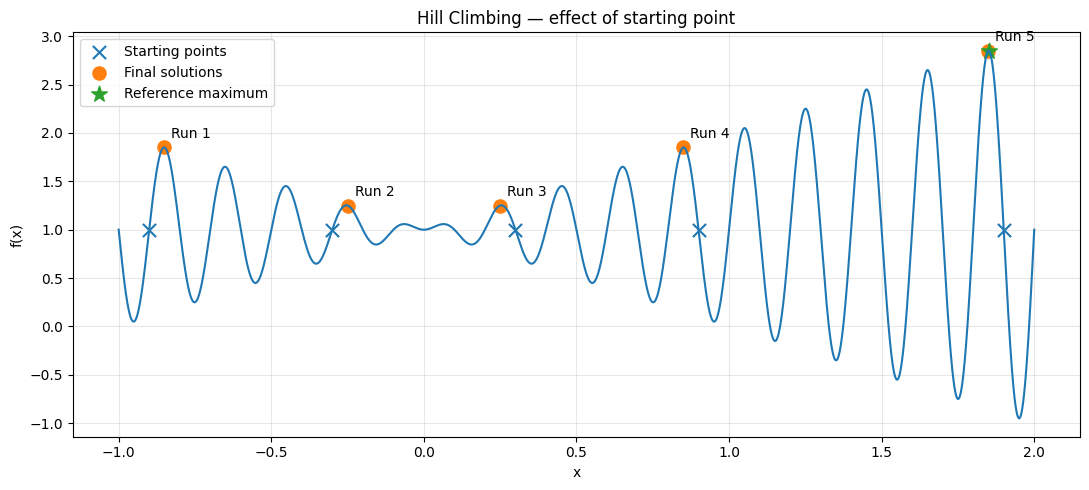

In [ ]:

plt.figure(figsize=(11, 5))
plt.plot(grid_x, grid_y, linewidth=1.5)

plt.scatter(
    hc_df["Initial x"],
    objective(hc_df["Initial x"].to_numpy()),
    marker="x",
    s=90,
    label="Starting points"
)

plt.scatter(
    hc_df["Final x"],
    hc_df["Final f(x)"],
    marker="o",
    s=90,
    label="Final solutions"
)

plt.scatter([REF_X], [REF_F], marker="*", s=140, label="Reference maximum")

for i, row in hc_df.iterrows():
    plt.annotate(
        f"Run {i+1}",
        (row["Final x"], row["Final f(x)"]),
        xytext=(5, 7),
        textcoords="offset points"
    )

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Hill Climbing — effect of starting point")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Hill Climbing interpretation checklist

After running the cell, answer:

- **Dependence on starting point:** Did the same algorithm finish in different final x values?
- **Local optimum:** Did any run stop at a peak below the reference maximum?
- **Quality:** Which run had the smallest gap?
- **Effort:** How many iterations did each run require?

Do not write the final conclusion until you inspect the actual table and graph.



# 4. Experiment B — Simulated Annealing

The exercise specifies:

- **Initial temperature = 100**
- **Cooling rates = 0.90, 0.95, 0.99**
- **Maximum iterations = 1,000**

The purpose is to study the effect of the cooling rate.

Unlike Hill Climbing, Simulated Annealing can temporarily accept a worse neighboring solution. This is the behavior we want to observe experimentally.

### Main indicators

- Best x
- Best f(x)
- Gap
- Number of worse moves accepted
- Mean best f(x) across repeated runs
- Standard deviation across repeated runs
- Success rate

Because Simulated Annealing is stochastic, we repeat every configuration several times.


In [ ]:

def simulated_annealing(
    initial_x=0.30,
    initial_temperature=100.0,
    cooling_rate=0.95,
    max_iterations=1_000,
    step_size=0.10,
    seed=0
):
    rng = np.random.default_rng(seed)

    current_x = float(initial_x)
    current_f = float(objective(current_x))

    best_x = current_x
    best_f = current_f

    temperature = float(initial_temperature)
    accepted_worse = 0

    trajectory = []

    for iteration in range(1, max_iterations + 1):
        candidate_x = current_x + rng.uniform(-step_size, step_size)
        candidate_x = float(np.clip(candidate_x, X_MIN, X_MAX))
        candidate_f = float(objective(candidate_x))

        delta = candidate_f - current_f

        accepted = False
        worse_move = False

        if delta >= 0:
            accepted = True
        elif temperature > 1e-12:
            probability = math.exp(delta / temperature)
            if rng.random() < probability:
                accepted = True
                worse_move = True

        if accepted:
            current_x = candidate_x
            current_f = candidate_f

            if worse_move:
                accepted_worse += 1

            if current_f > best_f:
                best_x = current_x
                best_f = current_f

        trajectory.append({
            "Iteration": iteration,
            "Current x": current_x,
            "Current f(x)": current_f,
            "Best x": best_x,
            "Best f(x)": best_f,
            "Temperature": temperature,
            "Accepted worse": accepted_worse
        })

        temperature *= cooling_rate

    return {
        "best_x": best_x,
        "best_f": best_f,
        "accepted_worse": accepted_worse,
        "trajectory": pd.DataFrame(trajectory)
    }



## 4.1 One illustrative run for each cooling rate

The same initial point and seed are used so the visual comparison focuses on the cooling rate.


In [ ]:

SA_COOLING_RATES = [0.90, 0.95, 0.99]
SA_INITIAL_X = 0.30
SA_T0 = 100.0
SA_ITERATIONS = 1_000
SA_STEP = 0.10
SA_EXAMPLE_SEED = BASE_SEED

sa_example_results = {}

for rate in SA_COOLING_RATES:
    sa_example_results[rate] = simulated_annealing(
        initial_x=SA_INITIAL_X,
        initial_temperature=SA_T0,
        cooling_rate=rate,
        max_iterations=SA_ITERATIONS,
        step_size=SA_STEP,
        seed=SA_EXAMPLE_SEED
    )

example_table = pd.DataFrame([
    {
        "Cooling rate": rate,
        "Best x": result["best_x"],
        "Best f(x)": result["best_f"],
        "Gap": gap_to_reference(result["best_f"]),
        "Accepted worse moves": result["accepted_worse"]
    }
    for rate, result in sa_example_results.items()
])

display(example_table)


,Cooling rate,Best x,Best f(x),Gap,Accepted worse moves
0,0.90,0.253981,1.251997,1.598277,32
1,0.95,0.651706,1.650770,1.199504,68
2,0.99,1.451164,2.450194,0.400080,253



### Trajectory graph

The graph below shows the **best value found so far** during the 1,000 iterations.

A second graph shows the **current f(x)** for the same runs. Drops in the current value are evidence that the algorithm accepted worse solutions temporarily.


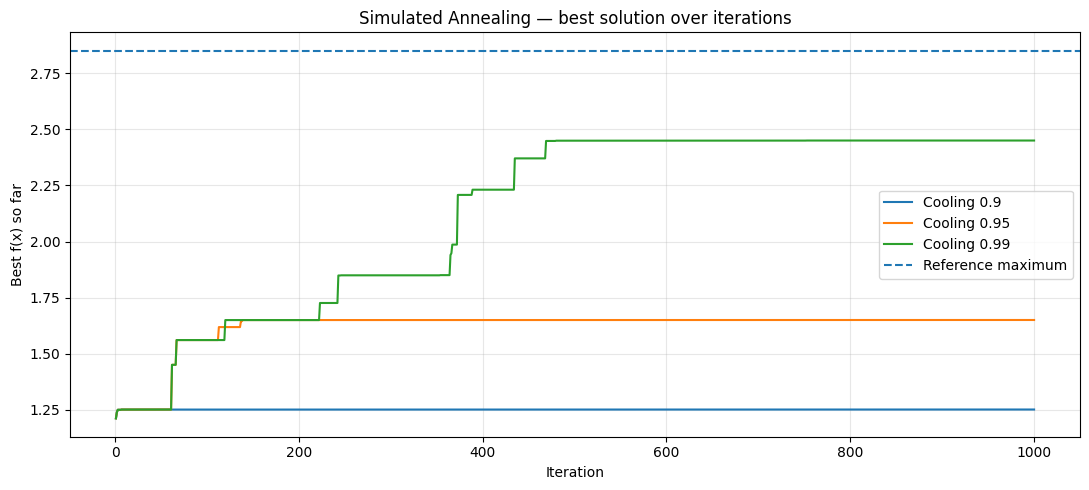

In [ ]:

plt.figure(figsize=(11, 5))

for rate, result in sa_example_results.items():
    traj = result["trajectory"]
    plt.plot(
        traj["Iteration"],
        traj["Best f(x)"],
        label=f"Cooling {rate}"
    )

plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Iteration")
plt.ylabel("Best f(x) so far")
plt.title("Simulated Annealing — best solution over iterations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


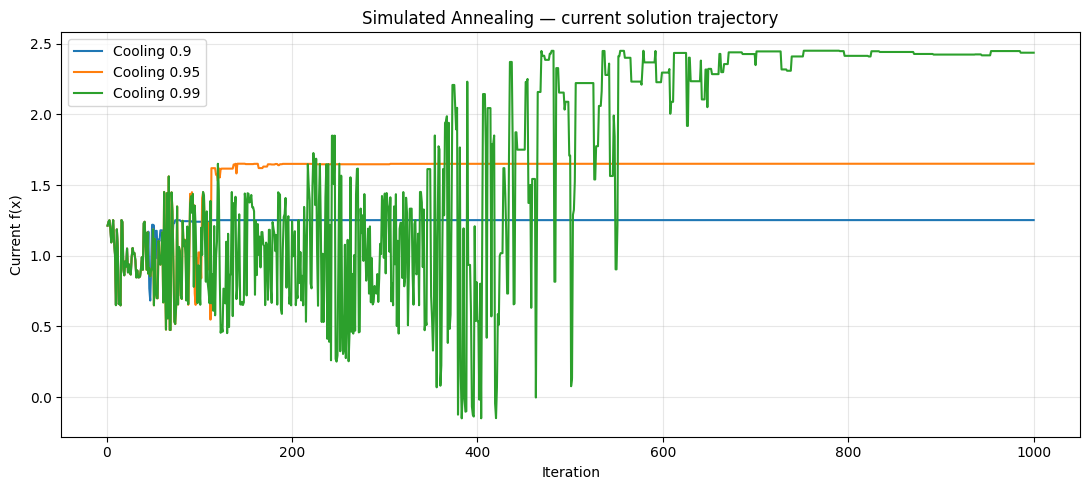

In [ ]:

plt.figure(figsize=(11, 5))

for rate, result in sa_example_results.items():
    traj = result["trajectory"]
    plt.plot(
        traj["Iteration"],
        traj["Current f(x)"],
        label=f"Cooling {rate}"
    )

plt.xlabel("Iteration")
plt.ylabel("Current f(x)")
plt.title("Simulated Annealing — current solution trajectory")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 4.2 Repeated experiment

A single stochastic run is not enough to evaluate stability.

The code below performs **30 repeated runs per cooling rate**. You may increase or reduce `SA_REPETITIONS`, but keep the same number for all three cooling rates.

### What to evaluate

- Higher **Mean best f(x)** is better.
- Lower **Gap** is better.
- Lower **standard deviation** means more stable repeated behavior.
- Higher **Success rate** means the method reaches the reference maximum more consistently.
- **Accepted worse moves** shows the mechanism that allows Simulated Annealing to escape local regions.


In [ ]:

SA_REPETITIONS = 30

sa_runs = []

for rate in SA_COOLING_RATES:
    for run in range(SA_REPETITIONS):
        result = simulated_annealing(
            initial_x=SA_INITIAL_X,
            initial_temperature=SA_T0,
            cooling_rate=rate,
            max_iterations=SA_ITERATIONS,
            step_size=SA_STEP,
            seed=BASE_SEED + run
        )

        sa_runs.append({
            "Cooling rate": rate,
            "Run": run + 1,
            "Best x": result["best_x"],
            "Best f(x)": result["best_f"],
            "Gap": gap_to_reference(result["best_f"]),
            "Accepted worse moves": result["accepted_worse"],
            "Success": (gap_to_reference(result["best_f"])) <= SUCCESS_TOL
        })

sa_runs_df = pd.DataFrame(sa_runs)

sa_summary = (
    sa_runs_df
    .groupby("Cooling rate")
    .agg(
        Mean_best_f=("Best f(x)", "mean"),
        SD_best_f=("Best f(x)", "std"),
        Mean_gap=("Gap", "mean"),
        Best_observed_f=("Best f(x)", "max"),
        Mean_accepted_worse=("Accepted worse moves", "mean"),
        Success_rate=("Success", "mean")
    )
    .reset_index()
)

sa_summary["Success_rate"] *= 100
display(sa_summary)


,Cooling rate,Mean_best_f,SD_best_f,Mean_gap,Best_observed_f,Mean_accepted_worse,Success_rate
0,0.90,1.497272,0.223187,1.353001,2.250405,30.833333,0.000000
1,0.95,1.664076,0.334459,1.186197,2.850254,61.600000,3.333333
2,0.99,2.182727,0.413244,0.667547,2.850256,279.233333,20.000000


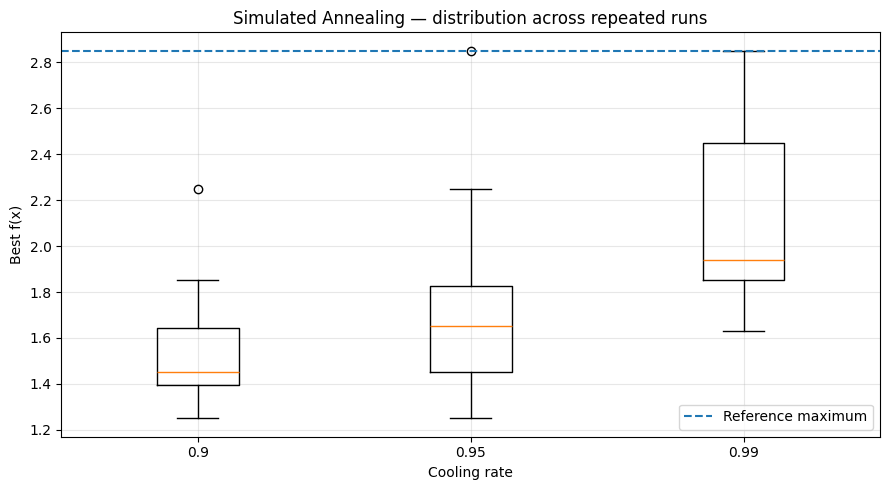

In [ ]:

plt.figure(figsize=(9, 5))
data_to_plot = [
    sa_runs_df.loc[sa_runs_df["Cooling rate"] == rate, "Best f(x)"].to_numpy()
    for rate in SA_COOLING_RATES
]

plt.boxplot(
    data_to_plot,
    tick_labels=[str(r) for r in SA_COOLING_RATES]
)
plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Cooling rate")
plt.ylabel("Best f(x)")
plt.title("Simulated Annealing — distribution across repeated runs")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Simulated Annealing interpretation checklist

1. Which cooling rate produced the largest mean best f(x)?
2. Which produced the smallest standard deviation?
3. Which achieved the highest success rate?
4. Did the trajectory contain temporary decreases in current f(x)?
5. After a temporary decrease, did the algorithm later find a better peak?
6. What changes when the system cools faster (0.90) versus more slowly (0.99)?

The actual results, not theory alone, must support the answers.



# 5. Experiment C — Genetic Algorithm

The exercise allows a binary or real-valued chromosome. This notebook uses a **real-valued chromosome**, where each individual is simply a candidate value of x.

The exercise asks us to experiment with:

- Population size
- Mutation probability
- Crossover probability
- Number of generations

We use **One Factor At a Time (OFAT)**:

> change one parameter while keeping the other parameters fixed.

This makes the interpretation much clearer.

### Key indicators

- Best f(x)
- Mean population fitness
- Gap
- Success rate
- Standard deviation across repeated runs
- Population diversity = standard deviation of x values in the population
- Generation when the best solution was first reached


In [ ]:

def genetic_algorithm(
    population_size=50,
    mutation_probability=0.10,
    crossover_probability=0.80,
    generations=100,
    mutation_sigma=0.10,
    tournament_size=3,
    seed=0
):
    rng = np.random.default_rng(seed)

    population = rng.uniform(X_MIN, X_MAX, population_size)

    best_x = None
    best_f = -np.inf
    best_generation = 0

    history = []

    def tournament_select(pop, scores):
        idx = rng.integers(0, len(pop), tournament_size)
        local_scores = scores[idx]
        return float(pop[idx[int(np.argmax(local_scores))]])

    for generation in range(generations):
        scores = objective(population)

        current_best_idx = int(np.argmax(scores))
        current_best_x = float(population[current_best_idx])
        current_best_f = float(scores[current_best_idx])

        if current_best_f > best_f:
            best_x = current_best_x
            best_f = current_best_f
            best_generation = generation

        history.append({
            "Generation": generation,
            "Best fitness": best_f,
            "Mean fitness": float(np.mean(scores)),
            "Diversity": float(np.std(population))
        })

        # Elitism: preserve the best solution found
        new_population = [best_x]

        while len(new_population) < population_size:
            p1 = tournament_select(population, scores)
            p2 = tournament_select(population, scores)

            # Arithmetic crossover
            if rng.random() < crossover_probability:
                alpha = rng.random()
                child = alpha * p1 + (1 - alpha) * p2
            else:
                child = p1

            # Mutation
            if rng.random() < mutation_probability:
                child += rng.normal(0, mutation_sigma)

            child = float(np.clip(child, X_MIN, X_MAX))
            new_population.append(child)

        population = np.array(new_population[:population_size])

    final_scores = objective(population)
    final_best_idx = int(np.argmax(final_scores))

    if float(final_scores[final_best_idx]) > best_f:
        best_x = float(population[final_best_idx])
        best_f = float(final_scores[final_best_idx])
        best_generation = generations

    return {
        "best_x": best_x,
        "best_f": best_f,
        "best_generation": best_generation,
        "history": pd.DataFrame(history)
    }



## 5.1 Baseline configuration

These are **experimental baseline values**, not values imposed by the professor:

- Population = 50
- Mutation probability = 0.10
- Crossover probability = 0.80
- Generations = 100

They give us a fixed reference configuration from which we can modify one factor at a time.


In [ ]:

GA_BASELINE = {
    "population_size": 50,
    "mutation_probability": 0.10,
    "crossover_probability": 0.80,
    "generations": 100
}

ga_baseline = genetic_algorithm(
    **GA_BASELINE,
    seed=BASE_SEED
)

print(f"Best x: {ga_baseline['best_x']:.6f}")
print(f"Best f(x): {ga_baseline['best_f']:.6f}")
print(f"Gap: {gap_to_reference(ga_baseline['best_f']):.6f}")
print(f"Best first reached at generation: {ga_baseline['best_generation']}")


Best x: 1.850547
Best f(x): 2.850274
Gap: 0.000000
Best first reached at generation: 25



## 5.2 Best fitness and mean fitness

This graph shows whether the population improves over generations.


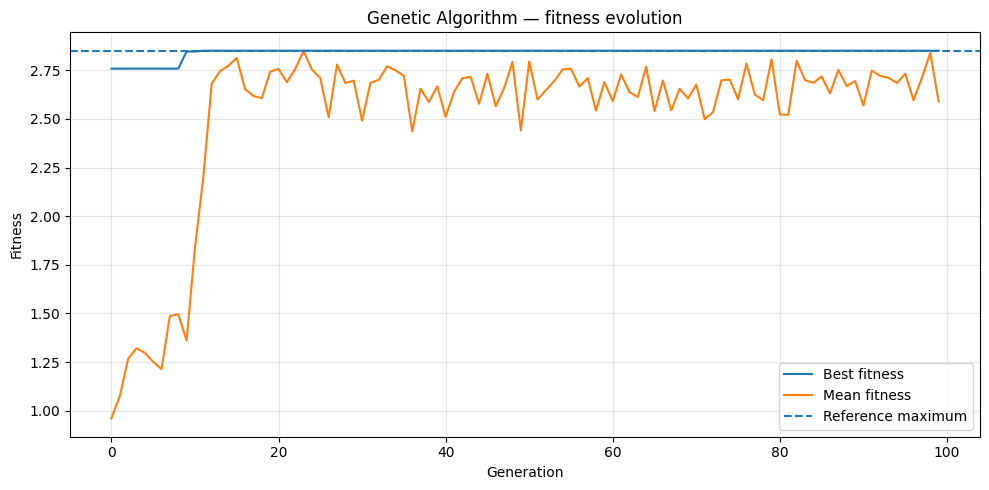

In [ ]:

ga_hist = ga_baseline["history"]

plt.figure(figsize=(10, 5))
plt.plot(ga_hist["Generation"], ga_hist["Best fitness"], label="Best fitness")
plt.plot(ga_hist["Generation"], ga_hist["Mean fitness"], label="Mean fitness")
plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Genetic Algorithm — fitness evolution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 5.3 Population diversity

For a one-dimensional real-valued population, diversity is measured as:

\[
D_t = SD(x_1,x_2,\ldots,x_N)
\]

- **High diversity**: individuals are spread over different regions.
- **Low diversity**: individuals are becoming similar.

A rapid fall in diversity combined with a poor final solution may indicate **premature convergence**.


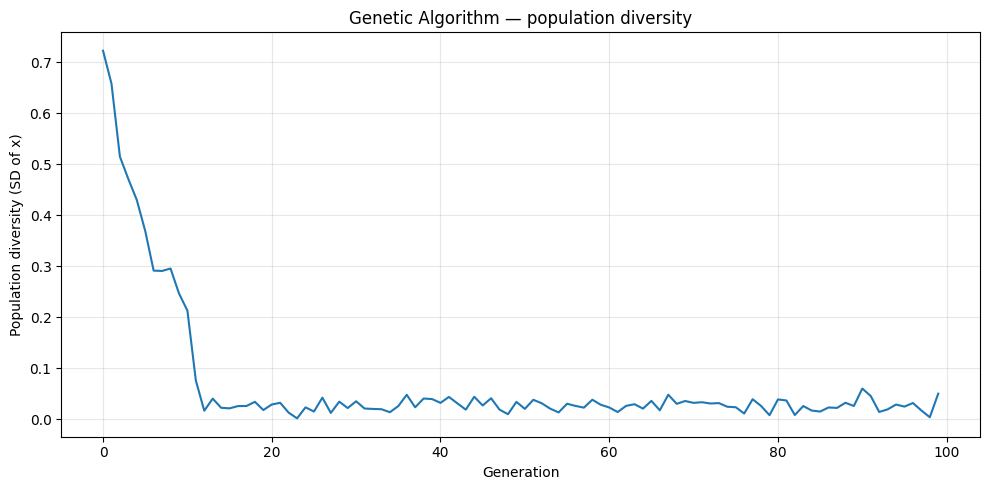

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(ga_hist["Generation"], ga_hist["Diversity"])
plt.xlabel("Generation")
plt.ylabel("Population diversity (SD of x)")
plt.title("Genetic Algorithm — population diversity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 5.4 Helper function for repeated GA experiments

Each parameter setting is repeated several times because the Genetic Algorithm is stochastic.


In [ ]:

GA_REPETITIONS = 20

def run_ga_factor_experiment(parameter_name, values, repetitions=GA_REPETITIONS):
    raw_rows = []

    for value in values:
        for run in range(repetitions):
            params = GA_BASELINE.copy()
            params[parameter_name] = value

            result = genetic_algorithm(
                **params,
                seed=BASE_SEED + run
            )

            final_diversity = float(result["history"]["Diversity"].iloc[-1])

            raw_rows.append({
                "Parameter": parameter_name,
                "Value": value,
                "Run": run + 1,
                "Best x": result["best_x"],
                "Best f(x)": result["best_f"],
                "Gap": gap_to_reference(result["best_f"]),
                "Final diversity": final_diversity,
                "Best generation": result["best_generation"],
                "Success": (gap_to_reference(result["best_f"])) <= SUCCESS_TOL
            })

    raw = pd.DataFrame(raw_rows)

    summary = (
        raw
        .groupby(["Parameter", "Value"])
        .agg(
            Mean_best_f=("Best f(x)", "mean"),
            SD_best_f=("Best f(x)", "std"),
            Mean_gap=("Gap", "mean"),
            Mean_final_diversity=("Final diversity", "mean"),
            Mean_best_generation=("Best generation", "mean"),
            Success_rate=("Success", "mean")
        )
        .reset_index()
    )

    summary["Success_rate"] *= 100
    return raw, summary



## 5.5 Experiment GA-1 — Population size

Only the population size changes.


In [ ]:

ga_pop_raw, ga_pop_summary = run_ga_factor_experiment(
    "population_size",
    [20, 50, 100]
)

display(ga_pop_summary)


,Parameter,Value,Mean_best_f,SD_best_f,Mean_gap,Mean_final_diversity,Mean_best_generation,Success_rate
0,population_size,20,2.748853,0.237787,1.014206e-01,0.031910,57.35,70.0
1,population_size,50,2.850270,0.000015,3.405941e-06,0.026775,40.10,100.0
2,population_size,100,2.850274,0.000000,-5.866189e-09,0.028477,29.05,100.0


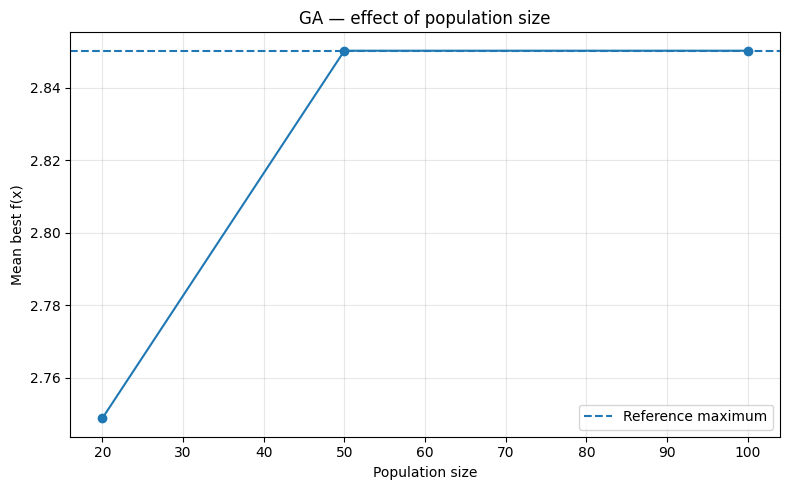

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(
    ga_pop_summary["Value"],
    ga_pop_summary["Mean_best_f"],
    marker="o"
)
plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Population size")
plt.ylabel("Mean best f(x)")
plt.title("GA — effect of population size")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Evaluate

- Does a larger population improve mean best fitness?
- Does it improve success rate?
- Does it preserve more diversity?
- Is the improvement large enough to justify the additional search effort?



## 5.6 Experiment GA-2 — Mutation probability

Only the mutation probability changes.


In [ ]:

ga_mut_raw, ga_mut_summary = run_ga_factor_experiment(
    "mutation_probability",
    [0.01, 0.10, 0.30]
)

display(ga_mut_summary)


,Parameter,Value,Mean_best_f,SD_best_f,Mean_gap,Mean_final_diversity,Mean_best_generation,Success_rate
0,mutation_probability,0.01,2.756320,1.577358e-01,9.395337e-02,0.002709,33.9,70.0
1,mutation_probability,0.10,2.850270,1.525624e-05,3.405941e-06,0.026775,40.1,100.0
2,mutation_probability,0.30,2.850274,2.363268e-11,-5.860898e-09,0.047613,42.3,100.0


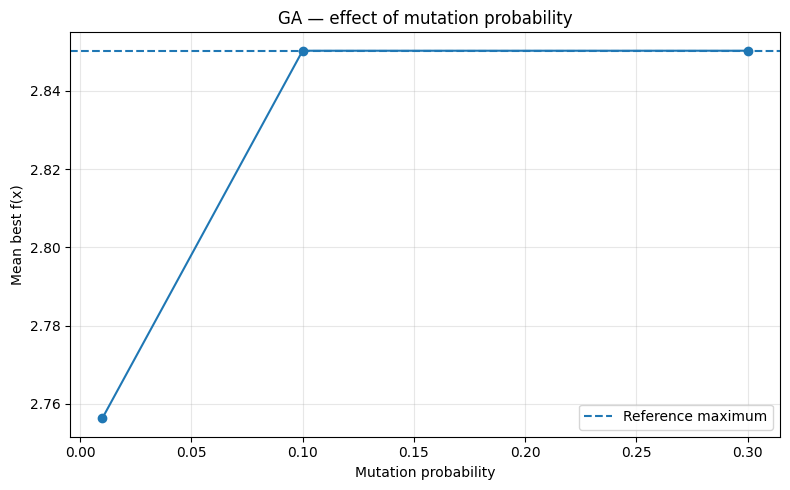

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(
    ga_mut_summary["Value"],
    ga_mut_summary["Mean_best_f"],
    marker="o"
)
plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Mutation probability")
plt.ylabel("Mean best f(x)")
plt.title("GA — effect of mutation probability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Evaluate

- Does very low mutation reduce exploration?
- Does higher mutation preserve diversity?
- Does too much mutation make the search less stable?
- Which mutation probability gives the best balance between fitness and diversity?



## 5.7 Experiment GA-3 — Crossover probability

Only the crossover probability changes.


In [ ]:

ga_cross_raw, ga_cross_summary = run_ga_factor_experiment(
    "crossover_probability",
    [0.50, 0.80, 1.00]
)

display(ga_cross_summary)


,Parameter,Value,Mean_best_f,SD_best_f,Mean_gap,Mean_final_diversity,Mean_best_generation,Success_rate
0,crossover_probability,0.5,2.850273,0.000001,3.524574e-07,0.030179,33.55,100.0
1,crossover_probability,0.8,2.850270,0.000015,3.405941e-06,0.026775,40.10,100.0
2,crossover_probability,1.0,2.827676,0.089567,2.259786e-02,0.030915,56.90,90.0


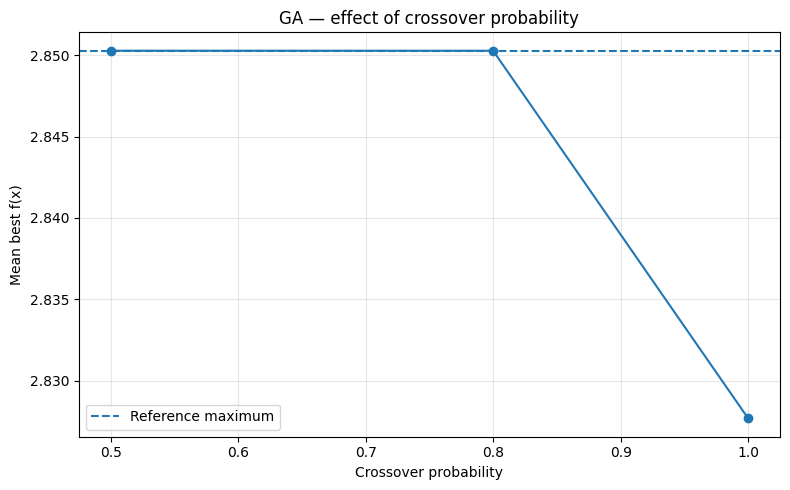

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(
    ga_cross_summary["Value"],
    ga_cross_summary["Mean_best_f"],
    marker="o"
)
plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Crossover probability")
plt.ylabel("Mean best f(x)")
plt.title("GA — effect of crossover probability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Evaluate

- Does more frequent crossover improve the average solution?
- Does the population become too homogeneous?
- Which setting produces the most stable repeated runs?



## 5.8 Experiment GA-4 — Number of generations

Only the number of generations changes.


In [ ]:

ga_gen_raw, ga_gen_summary = run_ga_factor_experiment(
    "generations",
    [25, 50, 100]
)

display(ga_gen_summary)


,Parameter,Value,Mean_best_f,SD_best_f,Mean_gap,Mean_final_diversity,Mean_best_generation,Success_rate
0,generations,25,2.761987,0.149454,0.088286,0.032595,21.5,65.0
1,generations,50,2.840074,0.044675,0.010199,0.028188,34.0,95.0
2,generations,100,2.850270,0.000015,0.000003,0.026775,40.1,100.0


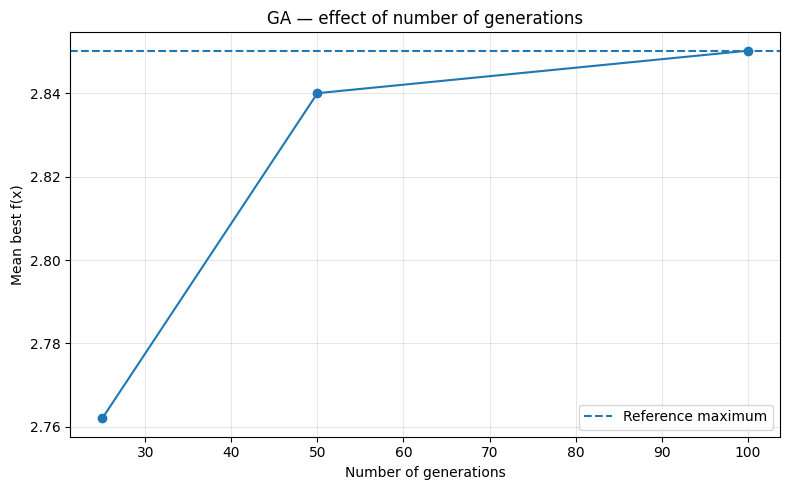

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(
    ga_gen_summary["Value"],
    ga_gen_summary["Mean_best_f"],
    marker="o"
)
plt.axhline(REF_F, linestyle="--", label="Reference maximum")
plt.xlabel("Number of generations")
plt.ylabel("Mean best f(x)")
plt.title("GA — effect of number of generations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Evaluate

- Does increasing the number of generations still improve the solution?
- At what point does the improvement become very small?
- Does the algorithm converge early even when more generations are available?



# 6. Repeated-run comparison

This section supports the research question:

> **Which algorithm gives the same/similar solution across repeated runs?**

We compare the variability of:

- Hill Climbing across the five required starting points;
- Simulated Annealing using a selected cooling rate;
- Genetic Algorithm using the baseline configuration.

You may change `SELECTED_SA_RATE` after reviewing the SA experiment.


> **Important:** Hill Climbing variability here comes from changing the required starting points, while SA and GA variability comes from repeated stochastic runs. The comparison is descriptive, not a formal statistical equivalence test.

In [ ]:

SELECTED_SA_RATE = 0.99
COMPARISON_REPETITIONS = 30

# Hill Climbing: five required starting-point experiments
hc_values = hc_df["Final f(x)"].to_numpy()

# Simulated Annealing: repeated runs with selected cooling rate
sa_selected = sa_runs_df[
    sa_runs_df["Cooling rate"] == SELECTED_SA_RATE
]["Best f(x)"].to_numpy()

# Genetic Algorithm: repeated baseline runs
ga_compare_values = []

for run in range(COMPARISON_REPETITIONS):
    result = genetic_algorithm(
        **GA_BASELINE,
        seed=BASE_SEED + run
    )
    ga_compare_values.append(result["best_f"])

comparison_df = pd.DataFrame([
    {
        "Algorithm": "Hill Climbing",
        "Runs": len(hc_values),
        "Mean best f(x)": np.mean(hc_values),
        "SD": np.std(hc_values, ddof=1),
        "Best observed": np.max(hc_values),
        "Mean gap": np.mean([gap_to_reference(v) for v in hc_values]),
        "Success rate (%)": np.mean([gap_to_reference(v) <= SUCCESS_TOL for v in hc_values]) * 100
    },
    {
        "Algorithm": f"Simulated Annealing ({SELECTED_SA_RATE})",
        "Runs": len(sa_selected),
        "Mean best f(x)": np.mean(sa_selected),
        "SD": np.std(sa_selected, ddof=1),
        "Best observed": np.max(sa_selected),
        "Mean gap": np.mean([gap_to_reference(v) for v in sa_selected]),
        "Success rate (%)": np.mean([gap_to_reference(v) <= SUCCESS_TOL for v in sa_selected]) * 100
    },
    {
        "Algorithm": "Genetic Algorithm (baseline)",
        "Runs": len(ga_compare_values),
        "Mean best f(x)": np.mean(ga_compare_values),
        "SD": np.std(ga_compare_values, ddof=1),
        "Best observed": np.max(ga_compare_values),
        "Mean gap": np.mean([gap_to_reference(v) for v in ga_compare_values]),
        "Success rate (%)": np.mean([gap_to_reference(v) <= SUCCESS_TOL for v in ga_compare_values]) * 100
    }
])

display(comparison_df)


,Algorithm,Runs,Mean best f(x),SD,Best observed,Mean gap,Success rate (%)
0,Hill Climbing,5,1.810000,0.654217,2.850000,1.040274,20.0
1,Simulated Annealing (0.99),30,2.182727,0.413244,2.850256,0.667547,20.0
2,Genetic Algorithm (baseline),30,2.850271,0.000012,2.850274,0.000002,100.0



## How to interpret the comparison

For repeated runs:

- **Higher mean best f(x)** = better average solution quality.
- **Lower SD** = more stable / repeatable.
- **Lower mean gap** = closer to the reference maximum.
- **Higher success rate** = reaches a near-global solution more consistently.

Do not declare a winner based on one metric alone. Report what each metric shows.



# 7. Research Questions — evidence to extract from your experiments

The Lab 2 guide asks five questions. Use your own generated tables and graphs as evidence.

### RQ1. Why does Hill Climbing become dependent on the starting point?

**Evidence to inspect:**
- `hc_df`
- final x values
- final f(x) values
- graph of starting and final points

**Expected type of reasoning:**  
If different initial x values converge to different peaks, the experiment demonstrates dependence on the starting region.

---

### RQ2. Can Simulated Annealing escape a local optimum?

**Evidence to inspect:**
- current-solution trajectory
- accepted worse moves
- later improvement in best f(x)

**Strong evidence:**  
The current f(x) decreases temporarily, yet a later iteration reaches a better peak.

---

### RQ3. What happens when the cooling rate is too high?

Use the terminology carefully:

- A **larger cooling factor** such as 0.99 means temperature decreases more slowly.
- A **smaller factor** such as 0.90 means faster cooling.

**Evidence to inspect:**
- mean best f(x)
- SD
- success rate
- accepted worse moves

Base your answer on the observed results rather than assuming the outcome.

---

### RQ4. How does population diversity affect GA?

**Evidence to inspect:**
- diversity curve
- mean final diversity under different parameter values
- best fitness and success rate

Look for cases in which diversity collapses rapidly and the algorithm stops improving. This can indicate premature convergence.

---

### RQ5. Which algorithm gives the same/similar solution across repeated runs?

**Evidence to inspect:**
- comparison table
- standard deviation
- mean gap
- success rate

A more repeatable method should show **low variability** together with **high-quality solutions**.



# 8. Final experimental record

After completing your runs, record your findings in this structure.

| Experiment | Parameter modified | Values tested | Main metric | What happened? |
|---|---|---|---|---|
| Hill Climbing | Starting x | five values | Final f(x), Gap | |
| Simulated Annealing | Cooling rate | 0.90, 0.95, 0.99 | Mean best f(x), SD, Success rate | |
| GA-1 | Population size | 20, 50, 100 | Mean best f(x), diversity | |
| GA-2 | Mutation probability | 0.01, 0.10, 0.30 | Mean best f(x), diversity | |
| GA-3 | Crossover probability | 0.50, 0.80, 1.00 | Mean best f(x), diversity | |
| GA-4 | Generations | 25, 50, 100 | Mean best f(x), convergence | |

This table is intentionally left for your interpretation after executing the experiments.
